## Loading the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt    #the library is really big and have some submodules (as .pyplot)
import seaborn as sns
import numpy as np

%matplotlib inline   
# "magic line" -> make sure that every plot generated is added to the notebook and not in a separate window

In [6]:
df = pd.read_csv('/Users/laracacador/Documents/Ironhack/Week_5/Day_1/amz_uk_price_prediction_dataset.csv')

## Initial exploration

In [7]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [10]:
df.shape

(2443651, 9)

In [11]:
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [15]:
df.select_dtypes("object").nunique().sort_values(ascending=False)

asin        2222742
title       2077591
category        296
dtype: int64

## 1. Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

In [28]:
frequency_table = df['category'].value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [26]:
top5_categories = df['category'].value_counts().head(5)
top5_categories 

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

In [13]:
df['category'].value_counts(normalize=True)

category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
                                            ...   
Alexa Built-In Devices                    0.000044
Motorbike Chassis                         0.000044
Plugs                                     0.000044
Smart Home Security & Lighting            0.000043
Smart Speakers                            0.000022
Name: proportion, Length: 296, dtype: float64

#### lot of categories (296!!), let's see if there is products that appear in MORE THAN ONE category:

In [19]:
multi = df.groupby('asin')['category'].nunique()    # asin = product ID
print((multi > 1).sum(), 'products appear in more than one category')

174825 products appear in more than one category


asin
0000060259    1
0000439983    1
0007107005    1
0007183038    1
0007236069    3
             ..
B0CL2CBX96    1
B0CL2CPY6J    1
B0CL2D96N1    1
B0CL2G37X3    1
B0CL2RGL8C    1
Name: category, Length: 2222742, dtype: int64

### Observations:
#### the category 'sports and outdoors' is the most frequent category, with approx 34% of the dataset (836 265 out of 2 443 651 rows)

#### we can observe a real discrepancy between 'sports and outdoors' and the other categories (all below 1% each)

#### it also seems that:
Sports & Outdoors                         
Beauty                                    
Handmade Clothing, Shoes & Accessories    
Bath & Body                               
Birthday Gifts 
#### are more "general categories" than the others, for example "Alexa Built-In Devices" could correspond to a category names "tech devices" or something like that + these 5 categories correspond to the top 5 most listed product categories

## Visualization

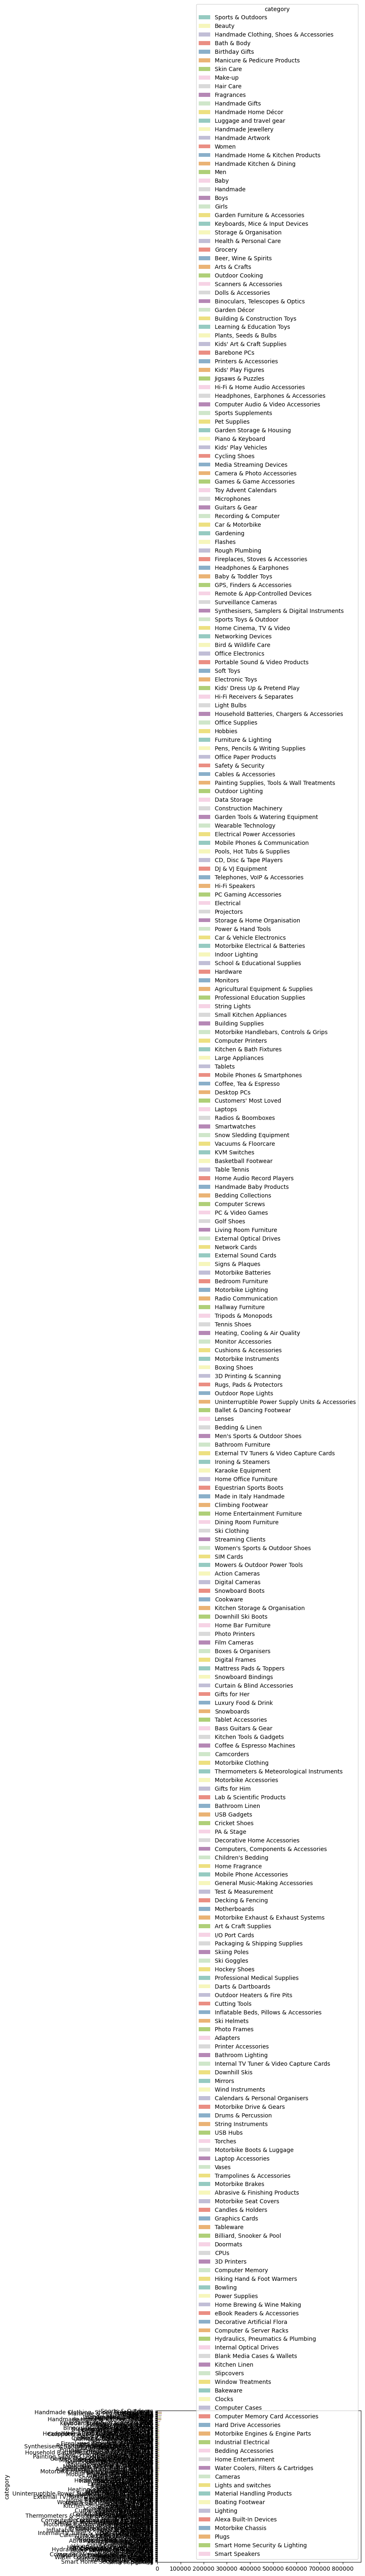

In [29]:
ax=sns.barplot(y=frequency_table.index, x=frequency_table.values, palette="Set3", hue=frequency_table.index, legend=True )
sns.move_legend(ax, "lower right")  

In [31]:
# just leaving this here even if it's not good practice, but this is a lab therefore i must and can show the fails....... 
# at least now i can see and read all categories eheh

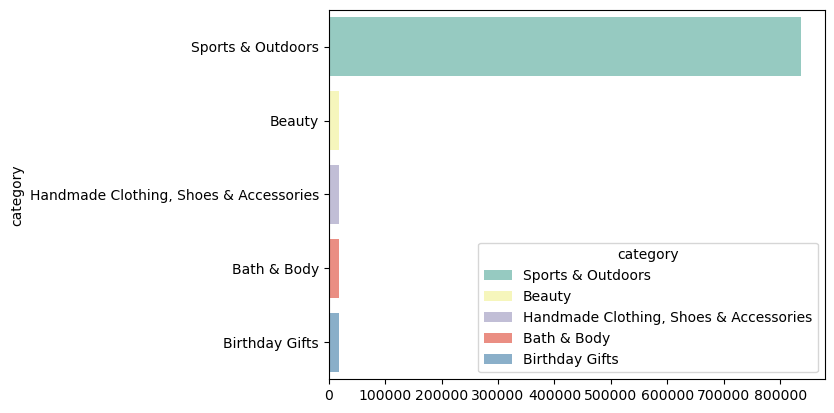

In [38]:
## let's use a subset of categories, our top5_categories
ax=sns.barplot(y=top5_categories.index, x=top5_categories.values, palette="Set3", hue=top5_categories.index, legend=True )
sns.move_legend(ax, "lower right")

In [39]:
# better bar chart now but it's difficult to understand how much products are in the 4 categories below the first one

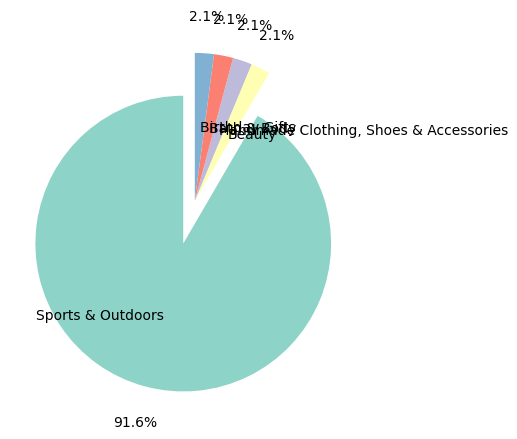

In [62]:
top5_categories.plot.pie(startangle=90,
                         colors=sns.color_palette("Set3"),
                         explode=(0.3, 0, 0, 0, 0),
                         autopct='%1.1f%%',
                         pctdistance=1.25,
                         labeldistance=0.5,
                         ylabel='')
plt.show()

#### as we can observe in the pie chart, and using the subset of category (top 5), sport and outdoors clearly stands out with a 91.6%

#### the other 4 categories are a mess, bc it's impossible to have them in the pie chart without overlapping each others

-----------

## 2.Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

### Measures of Centrality:

In [70]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print(f"The mean of price is: {mean_price}")
print(f"The median of price is: {median_price}")
print(f"The mode of price is: {mode_price}")

The mean of price is: 89.24380943923661
The median of price is: 19.09
The mode of price is: 9.99


In [74]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print(f"The mean of product's price is: {mean_price:.2f}")
print(f"The median of product's price is: {median_price:.2f}")
print(f"The mode of product's price is: {mode_price:.2f}")

The mean of product's price is: 89.24
The median of product's price is: 19.09
The mode of product's price is: 9.99


#### The average price point of products listed is ~89.24 £
#### However, compared to the median that a value of ~19.99£, we can observe an enormous gap between the two
#### So this means that the majority of products are relatively "cheap", but there is some values corresponding to extremely expensive items, hence the mean being pulled upward. 

#### Also, since we have this minority of products, we could say that they correspond to outliers, and that mean is not a good way to represent a typical price. In turn, median is more representative.

In [76]:
max_price = df['price'].max()
max_price

100000.0

In [ ]:
# 100_000 -> an outlier? 

### Measures of Dispersion:

In [90]:
range_price = max_price - min_price
quantiles_price = df['price'].quantile([0.25, 0.5, 0.75])

range_price, quantiles_price

(100000.0,
 0.25     9.99
 0.50    19.09
 0.75    45.99
 Name: price, dtype: float64)

In [91]:
variance_price = df['price'].var()
std_dev_price = df['price'].std()

variance_price, std_dev_price

(119445.4853225653, 345.6088617535223)

#### The quartiles show that 25% of products are priced below £9.99, 50% below £19.09, and 75% below £45.99

#### The standard deviation is ~£345.61, almost 4 times the mean!! (mean = £89.24) which confirm that some very expensive products are pushing the line

### Visualization:

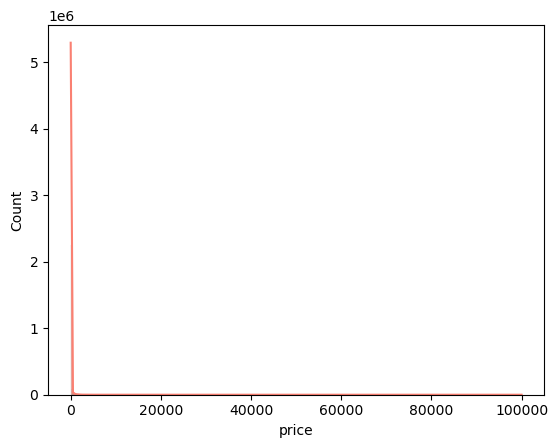

In [98]:
fig, axes = plt.subplots()
sns.histplot(df['price'], kde=True, bins=500, color="salmon", ax=axes);
plt.show()

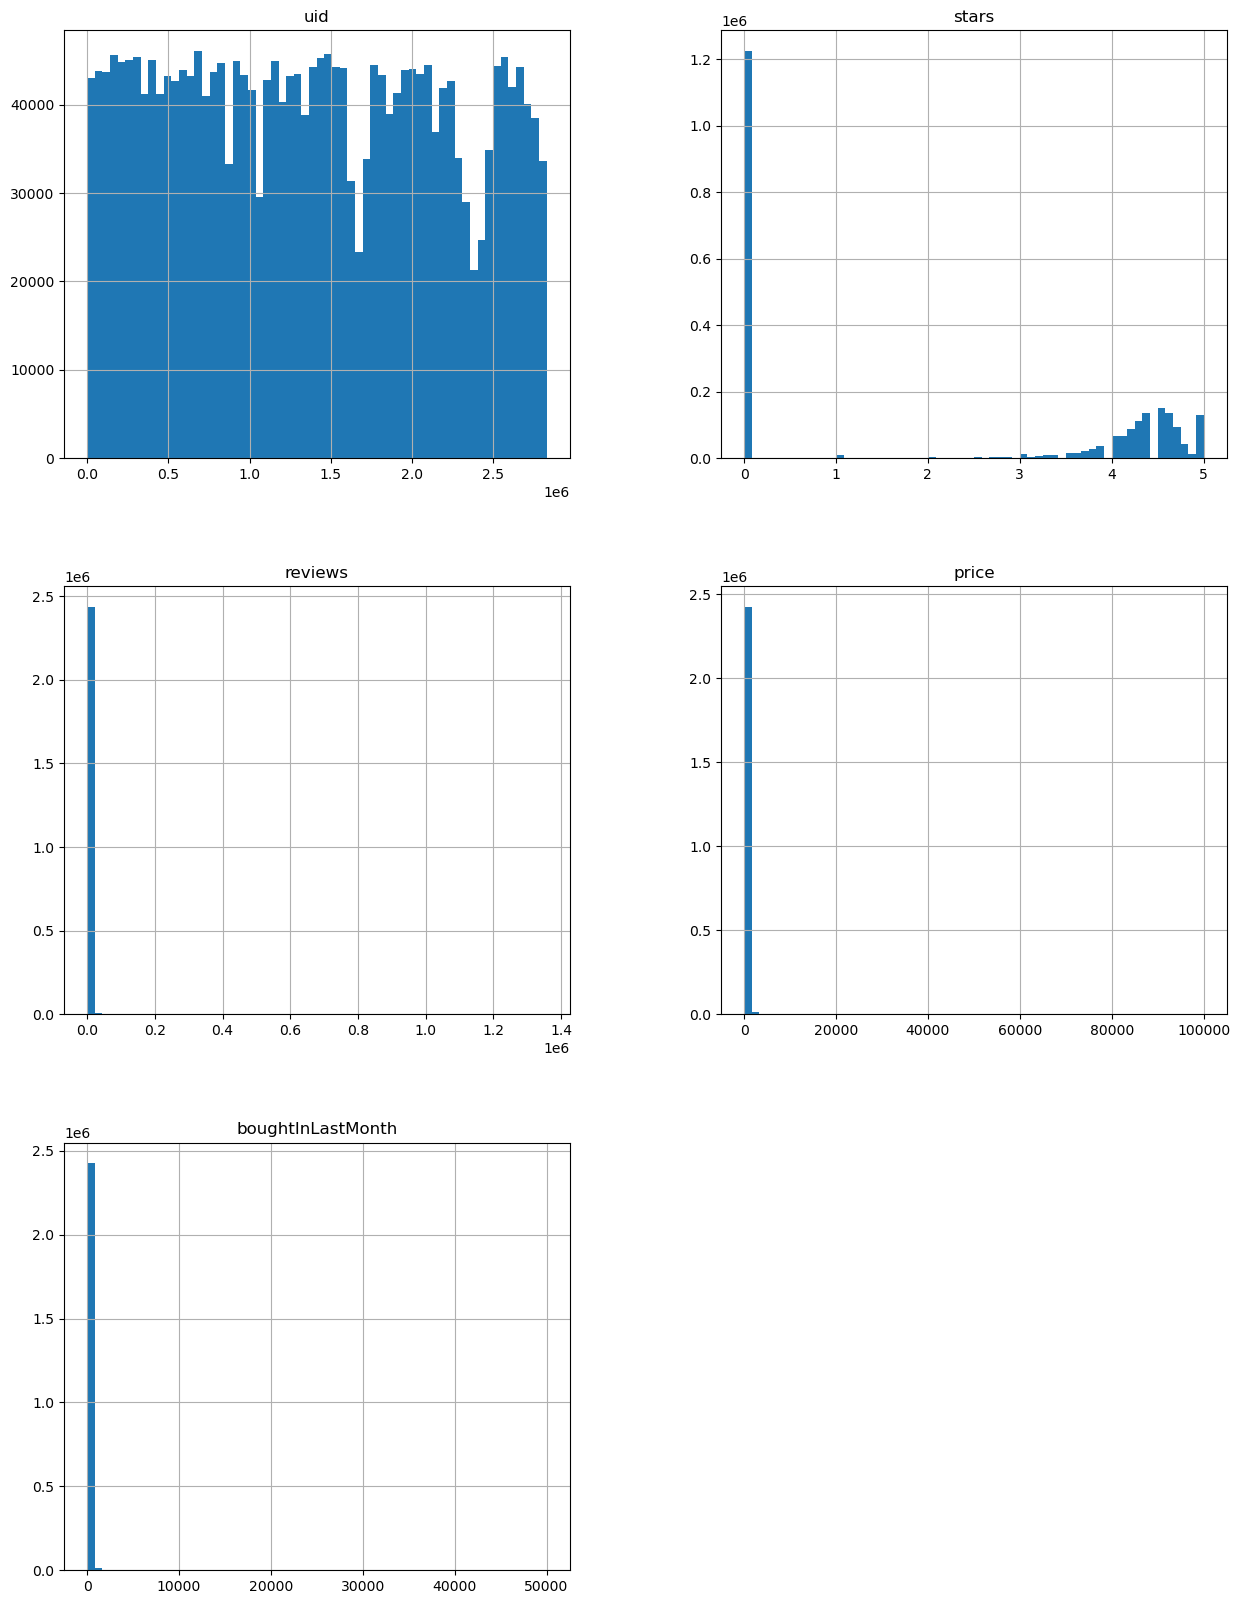

In [100]:
df.hist(figsize=(15, 20), bins=60, xlabelsize=10, ylabelsize=10);

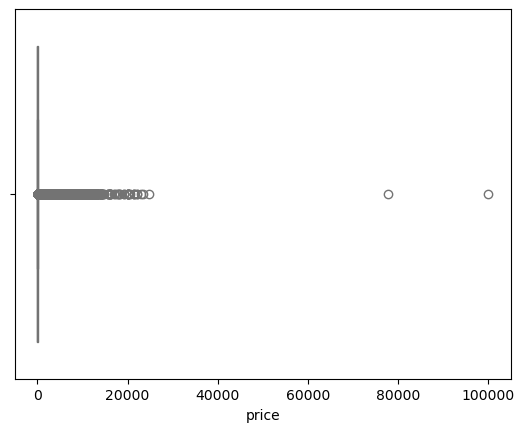

In [101]:
sns.boxplot(x = df['price'], color="lightgreen");

In [112]:
# Discretizing 'price' into categories
bins = [0, 20, 40, 80, 100, 200, 300, 400, 500,df['price'].max()]  
labels = ['very low', 'low', 'medium', 'mediumhigh', 'high', 'veryhigh', 'premium', 'premium+', 'luxury' ]

print(len(bins) - 1, 'intervals |', len(labels), 'labels')  

df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)
df['price_category'].value_counts().sort_index()

9 intervals | 9 labels


price_category
very low      1283743
low            488695
medium         282215
mediumhigh      61744
high           133238
veryhigh        56267
premium         30188
premium+        20056
luxury          87505
Name: count, dtype: int64

In [115]:
counts = df['price_category'].value_counts().sort_index()

first4 = counts.head(4).sum()
print(first4)    #very low, low, medium, mediumhigh 

2116397


In [118]:
counts = df['price_category'].value_counts().sort_index()

last5 = counts.tail(5).sum()
print(last5)    #high, veryhigh, premium, premium+, luxury

327254


#### Conclusion:

#### the histograms and the boxplot are illegible

#### that's why i decided to divide 'price' into different categories (binning 'price'):
##### - we can observe that the majority of products are priced between 0 and 100£ (2_116_397 products against 327_254 products with a price superior to 100£) which explains why the visualization charts are illegible, bc the majority of observations falls into the first bin
##### - also, the bins have not equal width, so ofc a wider bin will have more values

--------

## 3. Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

### Measures of Centrality:

In [120]:
mean_rating = df['stars'].mean()
median_rating = df['stars'].median()
mode_rating = df['stars'].mode()[0]

print(f"The mean of product's rating is: {mean_rating:.2f}")
print(f"The median of product's rating is: {median_rating:.2f}")
print(f"The mode of product's rating is: {mode_rating:.2f}")

The mean of product's rating is: 2.15
The median of product's rating is: 0.00
The mode of product's rating is: 0.00


In [ ]:
# mode and median with a value of zero? lets investigate

In [121]:
# Checking for missing data
df.isnull().sum().sort_values(ascending=False)

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
price_category       0
dtype: int64

#### it shows no missing data, HOWEVER, on the description of the dataset, it says that when a product is rated 0 , it's because no ratings were found
#### we should eliminate the zeros on the 'stars' column

In [126]:
count_unrated = (df['stars'] == 0).sum()

print(f"{count_unrated:_} products have no rating ({count_unrated/len(df):.1%})")   
#dividing the total of unrated products by the total amount of products

1_225_641 products have no rating (50.2%)


In [129]:
rated = df[df['stars'] > 0]

print(f"Rated products only (n = {len(rated):_}):")
print(f"  mean:   {rated['stars'].mean():.2f}")
print(f"  median: {rated['stars'].median():.2f}")
print(f"  mode:   {rated['stars'].mode()[0]:.2f}")

Rated products only (n = 1_218_010):
  mean:   4.32
  median: 4.40
  mode:   4.50


#### now, with the data 'cleaned' = knowing that 50% of products dont have a rating, we can affirm and observe that customers rated the products with an average of 4.32 stars, while the most frequent rating was 4.50

#### median, mode and mean are fairly simmetrical in their distribution

### Measures of Dispersion:

In [136]:
max_rating = rated['stars'].max()
min_rating = rated['stars'].min()
# because we dont want our "no reviews" to be accounted

max_rating, min_rating

(5.0, 1.0)

In [137]:
range_rating = max_rating - min_rating
quantiles_rating = rated['stars'].quantile([0.25, 0.5, 0.75])

range_rating, quantiles_rating

(4.0,
 0.25    4.1
 0.50    4.4
 0.75    4.6
 Name: stars, dtype: float64)

In [138]:
var_rating = rated['stars'].var()
std_rating = rated['stars'].std()

var_rating, std_rating

(0.30834337523805183, 0.5552867504614637)

#### we can observe:
##### - ratings of rated products, range from 1 to 5 stars
##### - the middle 50% of rated products falls between 4.1 and 4.6 stars
##### - the std deviation is only 0.56 stars, so ratings don't vary much -> almost everything sits around 4-4.5

### Shape of the Distribution:

In [141]:
skewness_rating = rated['stars'].skew()
kurtosis_rating = rated['stars'].kurtosis()

skewness_rating, kurtosis_rating

(np.float64(-2.379568112212799), np.float64(9.78193769066435))

#### skewness: The negative value of skewness (~0.08) for the 'stars' indicates that the distribution is left-skewed (the data pattern where the left side of the graph has a longer or stretched), which indicates a greater proportion of lower values(prices) on the left of the graph

#### Kurtosis: The positive kurtosis value of (~9.78) indicates a peak shape and more extreme outlier values

### Visualizations:

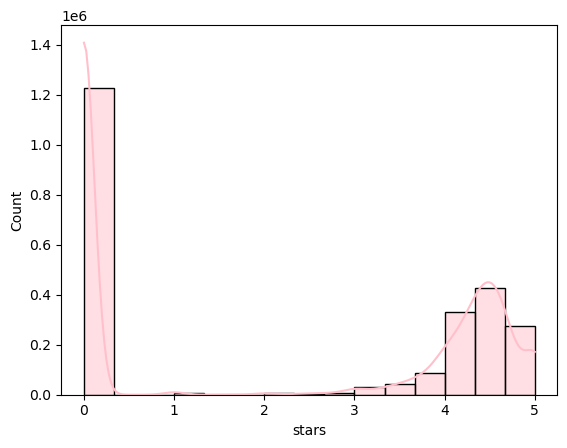

In [144]:
fig, axes = plt.subplots()
sns.histplot(df['stars'], kde=True, bins=15, color="pink", ax=axes);
plt.show()

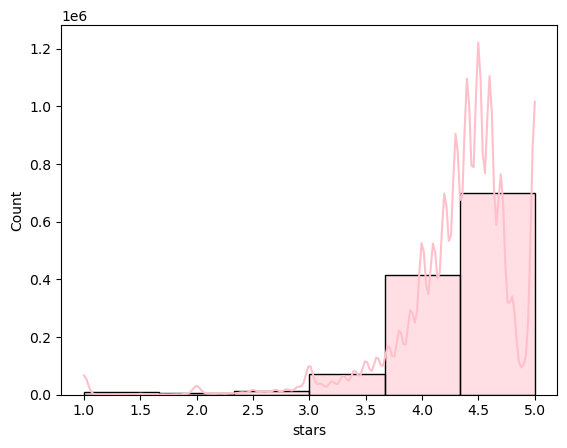

In [146]:
fig, axes = plt.subplots()
sns.histplot(rated['stars'], kde=True, bins=6, color="pink", ax=axes);
plt.show()

#### from what we can observe in the charts:
##### - 1st chart : there is a bin in the zero, corresponding to the ~50% of products with no ratings, as we saw previously
##### - the rating concentrates between 4 and 5, with a higher peak around 4.5 stars, which matches the results of the mean and mode we had calculated